# PubChem Taxonomy → BioAssay Master Table

This notebook builds a unified table mapping:

**Pathogen → Taxonomy ID (TaxID) → BioAssay ID (AID)**  

This notebook:
1. Loads each pathogen’s exported file  
2. Extracts and expands pipe-separated AIDs  
3. Builds one unified TaxID–AID table  
4. Computes summary statistics  
5. Saves processed outputs for downstream bioactivity retrieval

## 0. Setup

In [18]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import json
import requests

In [ ]:
NOTEBOOK_DIR = Path().resolve()
DATA_RAW = NOTEBOOK_DIR.parent / "data" / "raw"
DATA_PROCESSED = NOTEBOOK_DIR.parent / "data" / "processed"
DATA_PROCESSED.mkdir(exist_ok=True)

In [ ]:
pathogens = [
    "Acinetobacter baumannii", "Candida albicans", "Campylobacter",
    "Escherichia coli", "Enterococcus faecium", "Enterobacter",
    "Helicobacter pylori", "Klebsiella pneumoniae",
    "Mycobacterium tuberculosis", "Neisseria gonorrhoeae",
    "Pseudomonas aeruginosa", "Plasmodium falciparum",
    "Staphylococcus aureus", "Schistosoma mansoni",
    "Streptococcus pneumoniae"
]

## 1. Function to Load and Expand One Pathogen File

PubChem does not currently expose a stable API for retrieving
organism-linked BioAssays directly from organism names.
Therefore, the initial files used here were exported manually from:

**PubChem → Search → "Organism name" → Taxonomy →  
Actions → BioAssays → Download: *Summary (Search Results)***

Each exported CSV contains:
- `Taxonomy_ID`
- `Taxonomy_Name`
- `Linked_BioAssays` (pipe-separated AIDs)

Each CSV contains a pipe-separated list of linked BioAssays.
We expand these to one row per AID and annotate with the pathogen name.

In [3]:
def load_taxid_aid(pathogen: str) -> pd.DataFrame:
    """Load and expand the PubChem Taxonomy→BioAssay mapping for a pathogen."""
    
    filename = f"PubChem_taxonomy_text_{pathogen}.csv"
    filepath = DATA_RAW / filename

    df = pd.read_csv(filepath)

    # Keep relevant columns only + drop missing BioAssay rows
    df = (
        df[["Taxonomy_ID", "Taxonomy_Name", "Linked_BioAssays"]]
        .dropna(subset=["Linked_BioAssays"])
    )

    # Split AIDs from one colunm to one row/AID
    df["AID"] = df["Linked_BioAssays"].str.split("|")
    df = df.explode("AID")

    # Clean AID values and remove empty values
    df["AID"] = (
        df["AID"]
        .astype(str)
        .str.strip()
        .replace("", pd.NA)
        .replace("nan", pd.NA, regex=True)
    )

    df = df.dropna(subset=["AID"])

    # Convert only valid numerics
    df["AID"] = pd.to_numeric(df["AID"], errors="coerce")
    df = df.dropna(subset=["AID"])
    df["AID"] = df["AID"].astype(int)

    # Final clean table
    df = df[["Taxonomy_ID", "Taxonomy_Name", "AID"]].drop_duplicates()
    df["Pathogen"] = pathogen

    return df

## 2. Process All Pathogens

In [4]:
pathogen_tables = []

for pathogen in pathogens:
    print(f"Processing {pathogen}...")
    df_p = load_taxid_aid(pathogen)
    pathogen_tables.append(df_p)

df_all = pd.concat(pathogen_tables, ignore_index=True)
df_all = df_all[["Pathogen", "Taxonomy_ID", "Taxonomy_Name", "AID"]]
df_all.head()

Processing Acinetobacter baumannii...
Processing Candida albicans...
Processing Campylobacter...
Processing Escherichia coli...
Processing Enterococcus faecium...
Processing Enterobacter...
Processing Helicobacter pylori...
Processing Klebsiella pneumoniae...
Processing Mycobacterium tuberculosis...
Processing Neisseria gonorrhoeae...
Processing Pseudomonas aeruginosa...
Processing Plasmodium falciparum...
Processing Staphylococcus aureus...
Processing Schistosoma mansoni...
Processing Streptococcus pneumoniae...


,Pathogen,Taxonomy_ID,Taxonomy_Name,AID
0,Acinetobacter baumannii,575584,Acinetobacter baumannii ATCC 19606 = CIP 70.34...,1368269
1,Acinetobacter baumannii,575584,Acinetobacter baumannii ATCC 19606 = CIP 70.34...,1368280
2,Acinetobacter baumannii,575584,Acinetobacter baumannii ATCC 19606 = CIP 70.34...,1368291
3,Acinetobacter baumannii,575584,Acinetobacter baumannii ATCC 19606 = CIP 70.34...,1657590
4,Acinetobacter baumannii,400667,Acinetobacter baumannii ATCC 17978,485350


## 3. Summary Statistics

In [44]:
# Count number of AIDs per pathogen
summary_by_pathogen = (
    df_all.groupby("Pathogen")["AID"]
    .nunique()
    .reset_index(name="Taxonomy_AIDs")
    .sort_values("Taxonomy_AIDs", ascending=False)
    .reset_index(drop=True)
)

summary_by_pathogen

,Pathogen,Taxonomy_AIDs
0,Mycobacterium tuberculosis,3808
1,Escherichia coli,3415
2,Candida albicans,3114
3,Pseudomonas aeruginosa,2414
4,Enterobacter,2257
5,Plasmodium falciparum,1967
6,Staphylococcus aureus,1896
7,Streptococcus pneumoniae,1584
8,Klebsiella pneumoniae,1535
9,Acinetobacter baumannii,1442


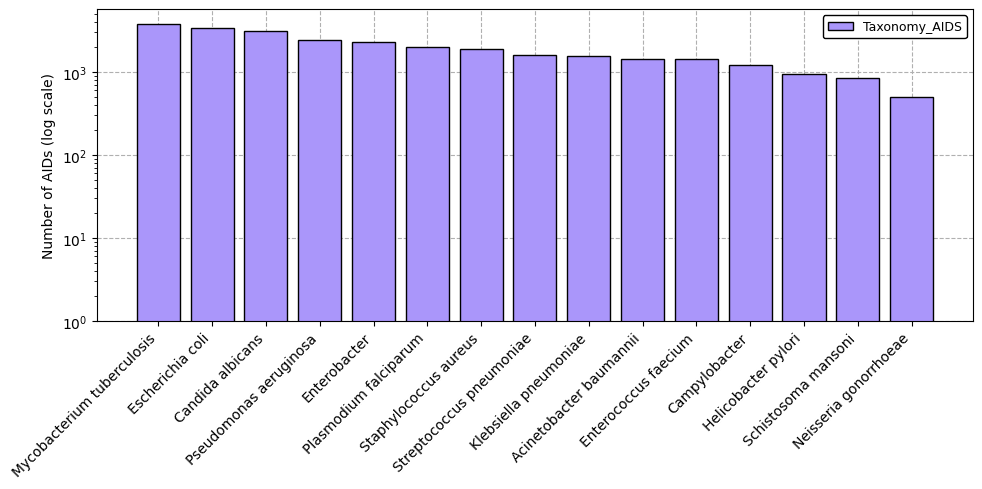

In [46]:
x = np.arange(len(summary_by_pathogen))

values = summary_by_pathogen["Taxonomy_AIDs"].values
labels = summary_by_pathogen["Pathogen"].values

# Plot
plt.figure(figsize=(10, 5))

plt.bar(
    x, values,
    color="#AA96FA",
    edgecolor="k",
    zorder=2,
    label="Taxonomy_AIDS"
)

plt.yscale("log")
plt.ylim(1, values.max() * 1.5)   # space above bars

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Number of AIDs (log scale)")

plt.grid(linestyle="--", zorder=1)
plt.legend(loc="upper right", framealpha=1, edgecolor="k", prop={"size": 9})

plt.tight_layout()
plt.show()

## 4. Save Outputs

In [ ]:
# Save final csv file with all Taxonomy_ID and AID pairs
df_all.to_csv(DATA_PROCESSED / "all_taxid_aid.csv", index=False)

print("Saved: all_taxid_aid.csv")

Saved: all_taxid_aid.csv


## 5. Build Taxonomy Table

Each pathogen corresponds to multiple
PubChem Taxonomy IDs (species, strains, variants, substrains).

Here we extract all TaxID entries present in the manually exported CSV files
and build:

1. A clean **taxonomy table** (`Pathogen`, `Taxonomy_ID`, `Taxonomy_Name`)
2. A **Python dictionary** mapping each pathogen to all its TaxIDs

This dictionary will be used later to retrieve the full set of BioAssays
linked to each organism from the full PubChem BioAssay dataset.

In [ ]:
# Extract the taxonomy IDs and names per pathogen
df_taxonomy = (
    df_all[["Pathogen", "Taxonomy_ID", "Taxonomy_Name"]]
    .drop_duplicates()
    .sort_values(["Pathogen", "Taxonomy_ID"])
    .reset_index(drop=True)
)

df_taxonomy.head(20)

,Pathogen,Taxonomy_ID,Taxonomy_Name
0,Acinetobacter baumannii,470,Acinetobacter baumannii
1,Acinetobacter baumannii,400667,Acinetobacter baumannii ATCC 17978
2,Acinetobacter baumannii,557601,Acinetobacter baumannii AB900
3,Acinetobacter baumannii,575584,Acinetobacter baumannii ATCC 19606 = CIP 70.34...
4,Acinetobacter baumannii,909768,Acinetobacter calcoaceticus/baumannii complex
5,Campylobacter,194,Campylobacter
6,Campylobacter,195,Campylobacter coli
7,Campylobacter,196,Campylobacter fetus
8,Campylobacter,197,Campylobacter jejuni
9,Campylobacter,199,Campylobacter concisus


In [15]:
# Convert taxonomy table into dictionary
dict_taxonomy = (
    df_taxonomy.groupby("Pathogen")["Taxonomy_ID"]
    .apply(list)
    .to_dict()
)

dict_taxonomy

{'Acinetobacter baumannii': [470, 400667, 557601, 575584, 909768],
 'Campylobacter': [194,
  195,
  196,
  197,
  199,
  205,
  210,
  824,
  827,
  28197,
  28198,
  32019,
  32022,
  192222,
  354242],
 'Candida albicans': [5476, 5482, 237561, 294748],
 'Enterobacter': [547,
  548,
  549,
  550,
  565,
  569,
  28141,
  42895,
  61645,
  61646,
  61647,
  61648,
  69218,
  69219,
  158836,
  336306,
  357240],
 'Enterococcus faecium': [1352, 37734],
 'Escherichia coli': [562,
  37762,
  83333,
  83334,
  199310,
  216592,
  217992,
  244320,
  316385,
  316407,
  364106,
  439184,
  439855,
  469008,
  481805,
  511145,
  511693,
  574521,
  585035,
  591946,
  634468,
  668369,
  679895,
  714962,
  749550,
  1090940,
  1206108,
  1322345],
 'Helicobacter pylori': [210, 85962, 85963, 102617, 102618, 290847, 357544],
 'Klebsiella pneumoniae': [573,
  574,
  72407,
  272620,
  507522,
  1162296,
  1263871,
  1267897,
  1276652,
  1276653],
 'Mycobacterium tuberculosis': [1719,
  1764,

In [17]:
# Save taxonomy table and dictionary

df_taxonomy.to_csv(DATA_PROCESSED / "taxonomy_table.csv", index=False)

with open(DATA_PROCESSED / "dict_taxonomy.json", "w") as f:
    json.dump(dict_taxonomy, f, indent=2)

print("Saved: taxonomy_table.csv and dict_taxonomy.json")

Saved: taxonomy_table.csv and dict_taxonomy.json


## 6. SDQ Query for Bioassays aid & taxids

In [27]:
def get_aids_for_taxid(taxid: int):
    """Return curated AIDs for a given TaxID from the PubChem taxonomy module."""
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/taxonomy/taxid/{taxid}/aids/JSON"
    r = requests.get(url)

    if r.status_code != 200:
        return []

    data = r.json()

    try:
        info = data["InformationList"]["Information"][0]
        return info.get("AID", [])
    except:
        return []

In [52]:
# For each pathogen, fetch curated AIDs
pugrest_aids_counts = {}

for pathogen, taxids in dict_taxonomy.items():
    aids = set()
    for tid in taxids:
        aids.update(get_aids_for_taxid(tid))
    pugrest_aids_counts[pathogen] = len(aids)

pugrest_aids_counts

{'Acinetobacter baumannii': 3286,
 'Campylobacter': 991,
 'Candida albicans': 11878,
 'Enterobacter': 1922,
 'Enterococcus faecium': 1857,
 'Escherichia coli': 17850,
 'Helicobacter pylori': 710,
 'Klebsiella pneumoniae': 5360,
 'Mycobacterium tuberculosis': 10290,
 'Neisseria gonorrhoeae': 468,
 'Plasmodium falciparum': 8229,
 'Pseudomonas aeruginosa': 12526,
 'Schistosoma mansoni': 718,
 'Staphylococcus aureus': 30774,
 'Streptococcus pneumoniae': 4012}

In [ ]:
# Comparison with previous strategy
summary_by_pathogen["PUGREST_AIDs"] = summary_by_pathogen["Pathogen"].map(pugrest_aids_counts)
summary_by_pathogen = summary_by_pathogen.sort_values("Taxonomy_AIDs", ascending=False).reset_index(drop=True)

summary_by_pathogen

,Pathogen,Taxonomy_AIDs,PUGREST_AIDs
0,Mycobacterium tuberculosis,3808,10290
1,Escherichia coli,3415,17850
2,Candida albicans,3114,11878
3,Pseudomonas aeruginosa,2414,12526
4,Enterobacter,2257,1922
5,Plasmodium falciparum,1967,8229
6,Staphylococcus aureus,1896,30774
7,Streptococcus pneumoniae,1584,4012
8,Klebsiella pneumoniae,1535,5360
9,Acinetobacter baumannii,1442,3286


Let's also add the manually search bioassays count:

In [55]:
# Add UI (user interface) counts (PubChem website search)
ui_counts = {
    "Acinetobacter baumannii": 15778,
    "Candida albicans": 23814,
    "Campylobacter": 622,
    "Escherichia coli": 63263,
    "Enterococcus faecium": 3864,
    "Enterobacter": 4023,
    "Helicobacter pylori": 1670,
    "Klebsiella pneumoniae": 11883,
    "Mycobacterium tuberculosis": 25323,
    "Neisseria gonorrhoeae": 1019,
    "Pseudomonas aeruginosa": 26093,
    "Plasmodium falciparum": 24519,
    "Staphylococcus aureus": 59672,
    "Schistosoma mansoni": 1276,
    "Streptococcus pneumoniae": 9474
}

summary_by_pathogen["PubChem_Web_AIDs"] = summary_by_pathogen["Pathogen"].map(ui_counts)
summary_by_pathogen = summary_by_pathogen.sort_values("PubChem_Web_AIDs", ascending=False).reset_index(drop=True)

summary_by_pathogen

,Pathogen,Taxonomy_AIDs,PUGREST_AIDs,PubChem_Web_AIDs
0,Escherichia coli,3415,17850,63263
1,Staphylococcus aureus,1896,30774,59672
2,Pseudomonas aeruginosa,2414,12526,26093
3,Mycobacterium tuberculosis,3808,10290,25323
4,Plasmodium falciparum,1967,8229,24519
5,Candida albicans,3114,11878,23814
6,Acinetobacter baumannii,1442,3286,15778
7,Klebsiella pneumoniae,1535,5360,11883
8,Streptococcus pneumoniae,1584,4012,9474
9,Enterobacter,2257,1922,4023


The two PubChem methods (CSV Taxonomy export vs PUG REST taxonomy→aids) return different and only partially overlapping assay sets, and the direction of the discrepancy varies by pathogen.

Let's also add the manually search bioassays count:

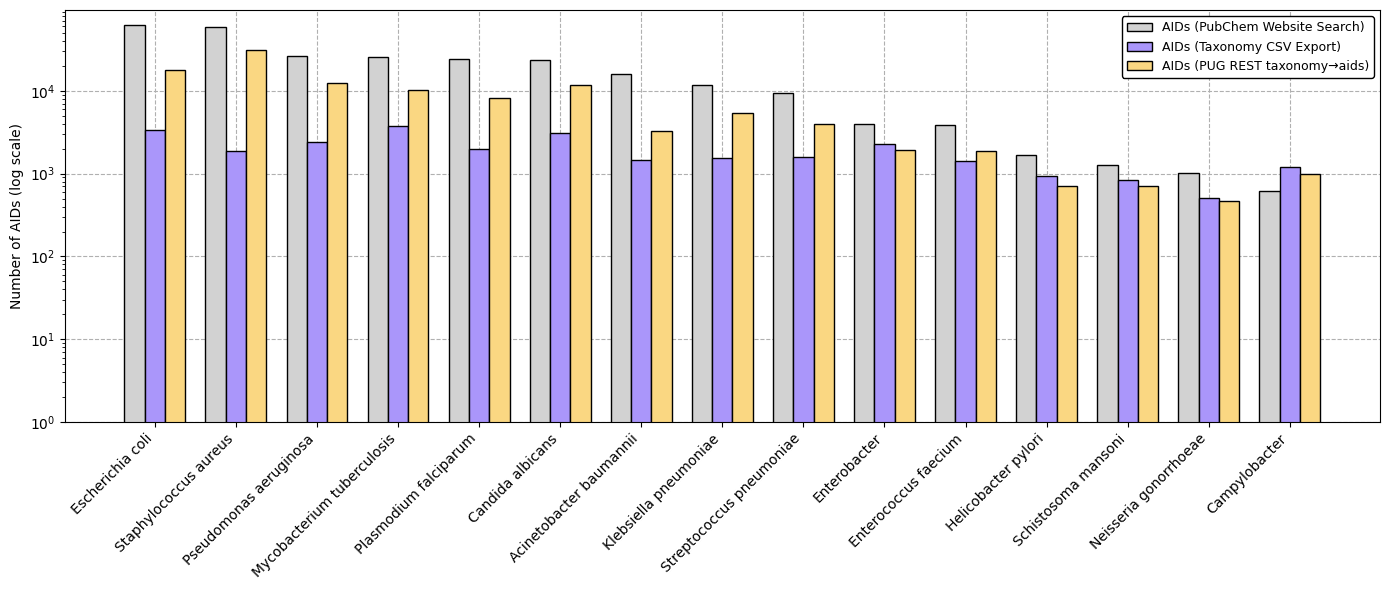

In [ ]:
# Extract arrays
labels          = summary_by_pathogen["Pathogen"].values
PubChem_Web_AIDs = summary_by_pathogen["PubChem_Web_AIDs"].values
Taxonomy_AIDs    = summary_by_pathogen["Taxonomy_AIDs"].values
PUGREST_AIDs     = summary_by_pathogen["PUGREST_AIDs"].values

N = len(labels)
x = np.arange(N)

bar_width = 0.25

plt.figure(figsize=(14, 6))

# LEFT BAR → PubChem Web UI (gray)
plt.bar(
    x - bar_width,
    PubChem_Web_AIDs,
    width=bar_width,
    color="#D2D2D2",
    ec="black",
    zorder=2,
    label="AIDs (PubChem Website Search)"
)

# MIDDLE BAR → Taxonomy CSV (purple)
plt.bar(
    x,
    Taxonomy_AIDs,
    width=bar_width,
    color="#AA96FA",
    ec="black",
    zorder=2,
    label="AIDs (Taxonomy CSV Export)"
)

# RIGHT BAR → PUG REST (yellow)
plt.bar(
    x + bar_width,
    PUGREST_AIDs,
    width=bar_width,
    color="#FAD782",
    ec="black",
    zorder=2,
    label="AIDs (PUG REST taxonomy→aids)"
)

# Aesthetics
plt.yscale("log")
plt.ylim([1, PubChem_Web_AIDs.max() * 1.5])

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Number of AIDs (log scale)")

plt.grid(linestyle="--", zorder=1)
plt.legend(loc="upper right", framealpha=1, edgecolor="k", prop={"size": 9})

plt.tight_layout()
plt.show()

## 7. PubChem’s Aid2Taxid.tsv.gz file

To obtain a complete and unbiased list of all BioAssays linked to our taxonomy IDs, we now switch to PubChem’s official FTP file Aid2Taxid.tsv.gz, which contains the full mapping of every PubChem BioAssay (including ChEMBL-imported assays) to all associated NCBI Taxonomy IDs—ensuring no assays are missed, unlike the previous UI-based or PUG-REST methods.

This file was downloaded manually from:

https://ftp.ncbi.nlm.nih.gov/pubchem/Bioassay/Extras/Aid2Taxid.gz

In [63]:
# Load file

df_aid2tax = pd.read_csv(DATA_RAW / "Aid2Taxid.tsv", sep="\t")
df_aid2tax.head(10)

,AID,TaxID
0,1398771,10090
1,1398772,10090
2,1398788,9606
3,1398789,9606
4,1398790,9606
5,1398791,9606
6,1398805,9606
7,1398806,9606
8,1398808,9606
9,1398822,9606


In [67]:
# 1. Build pathogen–TaxID lookup
rows = []
for pathogen, taxids in dict_taxonomy.items():
    for tax in taxids:
        rows.append({"Pathogen": pathogen, "TaxID": tax})

df_tax_lookup = pd.DataFrame(rows)

# 2. Merge and extract all matching AIDs
df_merged = df_aid2tax.merge(df_tax_lookup, on="TaxID", how="inner")
df_merged.head()

,AID,TaxID,Pathogen
0,1399257,1280,Staphylococcus aureus
1,1399258,1313,Streptococcus pneumoniae
2,1399258,171101,Streptococcus pneumoniae
3,1399274,562,Escherichia coli
4,1399275,562,Escherichia coli


In [69]:
# 3. Count AIDs per pathogen
summary_aid2tax = (
    df_merged.groupby("Pathogen")["AID"]
    .nunique()
    .reset_index(name="Aid2Taxid_AIDs")
    .sort_values("Aid2Taxid_AIDs", ascending=False)
    .reset_index(drop=True)
)

summary_aid2tax

,Pathogen,Aid2Taxid_AIDs
0,Staphylococcus aureus,26779
1,Escherichia coli,20139
2,Pseudomonas aeruginosa,11149
3,Candida albicans,10449
4,Mycobacterium tuberculosis,10037
5,Plasmodium falciparum,8148
6,Klebsiella pneumoniae,4477
7,Streptococcus pneumoniae,4192
8,Acinetobacter baumannii,2405
9,Enterobacter,1861


In [72]:
aid2tax_dict = dict(zip(summary_aid2tax["Pathogen"], summary_aid2tax["Aid2Taxid_AIDs"]))
summary_by_pathogen["Aid2Taxid_AIDs"] = summary_by_pathogen["Pathogen"].map(aid2tax_dict)
summary_by_pathogen = summary_by_pathogen.sort_values("PubChem_Web_AIDs", ascending=False).reset_index(drop=True)

summary_by_pathogen

,Pathogen,Taxonomy_AIDs,PUGREST_AIDs,PubChem_Web_AIDs,Aid2Taxid_AIDs
0,Escherichia coli,3415,17850,63263,20139
1,Staphylococcus aureus,1896,30774,59672,26779
2,Pseudomonas aeruginosa,2414,12526,26093,11149
3,Mycobacterium tuberculosis,3808,10290,25323,10037
4,Plasmodium falciparum,1967,8229,24519,8148
5,Candida albicans,3114,11878,23814,10449
6,Acinetobacter baumannii,1442,3286,15778,2405
7,Klebsiella pneumoniae,1535,5360,11883,4477
8,Streptococcus pneumoniae,1584,4012,9474,4192
9,Enterobacter,2257,1922,4023,1861


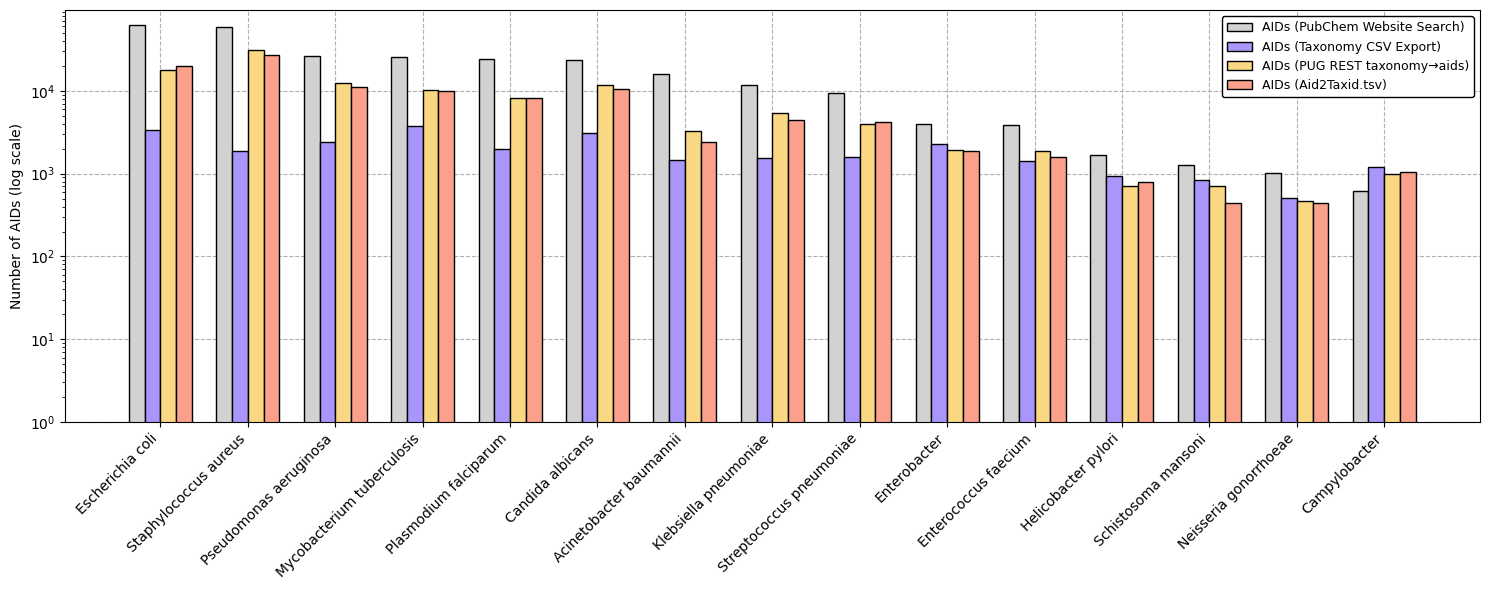

In [73]:
# Extract arrays
labels           = summary_by_pathogen["Pathogen"].values
PubChem_Web_AIDs = summary_by_pathogen["PubChem_Web_AIDs"].values
Taxonomy_AIDs    = summary_by_pathogen["Taxonomy_AIDs"].values
PUGREST_AIDs     = summary_by_pathogen["PUGREST_AIDs"].values
Aid2Taxid_AIDs   = summary_by_pathogen["Aid2Taxid_AIDs"].values

N = len(labels)
x = np.arange(N)

bar_width = 0.18   # narrower to fit 4 bars

plt.figure(figsize=(15, 6))

# 1. LEFT BAR → PubChem Web UI (gray)
plt.bar(
    x - 1.5*bar_width,
    PubChem_Web_AIDs,
    width=bar_width,
    color="#D2D2D2",
    ec="black",
    zorder=2,
    label="AIDs (PubChem Website Search)"
)

# 2. SECOND BAR → Taxonomy CSV (purple)
plt.bar(
    x - 0.5*bar_width,
    Taxonomy_AIDs,
    width=bar_width,
    color="#AA96FA",
    ec="black",
    zorder=2,
    label="AIDs (Taxonomy CSV Export)"
)

# 3. THIRD BAR → PUG REST (yellow)
plt.bar(
    x + 0.5*bar_width,
    PUGREST_AIDs,
    width=bar_width,
    color="#FAD782",
    ec="black",
    zorder=2,
    label="AIDs (PUG REST taxonomy→aids)"
)

# 4. RIGHT BAR → Aid2Taxid (salmon)
plt.bar(
    x + 1.5*bar_width,
    Aid2Taxid_AIDs,
    width=bar_width,
    color="#FAA08B",
    ec="black",
    zorder=2,
    label="AIDs (Aid2Taxid.tsv)"
)

# Aesthetics
plt.yscale("log")
plt.ylim([1, max(PubChem_Web_AIDs) * 1.5])

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Number of AIDs (log scale)")

plt.grid(linestyle="--", zorder=1)
plt.legend(loc="upper right", framealpha=1, edgecolor="k", prop={"size": 9})

plt.tight_layout()
plt.show()

The comparison shows that the **manual taxonomy-CSV** export captures the fewest assays, while both **PUG REST (taxonomy→aids)** and **Aid2Taxid.tsv** recover many more—almost identical to each other—because they rely on the same structured taxonomy annotations deposited in PubChem.

However, both still fall below the counts shown on the **PubChem website**, meaning many assays mentioning a pathogen are not formally annotated with a `TaxID` and only appear in the website search because they contain the organism name somewhere in their free-text descriptions.

To capture all these additional assays, we now need to process the **full PubChem BioAssay dataset** and search for pathogen names directly **inside text fields**:

- `BioAssay Name`
- `BioAssay Types`
- `Project Category`
- `Source Name`
- `Source ID`
- `BioAssay Group`

This free-text search will allow us to recover the assays that PubChem displays on the website but does not structurally tag with taxonomy IDs.